## Dataset Description: College Scorecard

The **College Scorecard** dataset from the U.S. Department of Education contains comprehensive data on U.S. colleges and universities, including admission rates, student demographics, costs, and outcomes.

### Task:
Predict whether an institution is **selective** (admission rate < 50%) based on institutional characteristics and student demographics.

### Key Columns:
- **SCHOOL_NAME**: Institution name
- **ADMISSION_RATE**: Overall admission rate (used to create target)
- **SAT_AVG**: Average SAT scores
- **STUDENT_SIZE**: Undergraduate enrollment
- **PREDOMINANT_DEGREE**: Predominant degree awarded
- **LOCALE**: Institution locale (city, suburb, town, rural)
- **PCT_WHITE/BLACK/HISPANIC/ASIAN**: Race/ethnicity demographic percentages
- **PCT_FEMALE**: Percentage of female students
- **PELL_RATE**: Percent receiving Pell Grants (socioeconomic proxy)
- **SELECTIVE**: Target variable (1: admission rate < 50%, 0: otherwise)

### Fairness Considerations:
Sensitive attributes include **race/ethnicity demographics**, **PCT_FEMALE** (gender), and **PELL_RATE** (socioeconomic status).

## 1. Data Downloading
Downloading College Scorecard data from the U.S. Department of Education API.

In [4]:
import os
import pandas as pd
import numpy as np
import requests
from sklearn.model_selection import train_test_split
import time

DATASET_NAME = "college-scorecard"
API_KEY = "b2uiD1hLpLFGxckoJZ1TdcOdsmf5c5GQSeExcRTe"
BASE_URL = "https://api.data.gov/ed/collegescorecard/v1/schools"

OUTPUT_DIR = f"../../resources/datasets/{DATASET_NAME}"
os.makedirs(OUTPUT_DIR, exist_ok=True)

# Define fields to fetch
fields = [
    "id",
    "school.name",
    "school.state",
    "school.city",
    "school.locale",
    "school.degrees_awarded.predominant",
    "latest.admissions.admission_rate.overall",
    "latest.admissions.sat_scores.average.overall",
    "latest.student.size",
    "latest.student.demographics.race_ethnicity.white",
    "latest.student.demographics.race_ethnicity.black",
    "latest.student.demographics.race_ethnicity.hispanic",
    "latest.student.demographics.race_ethnicity.asian",
    "latest.student.demographics.race_ethnicity.aian",
    "latest.student.demographics.race_ethnicity.nhpi",
    "latest.student.demographics.female_share",
    "latest.aid.pell_grant_rate",
    "latest.cost.tuition.in_state",
    "latest.completion.completion_rate_4yr_150nt",
]

fields_str = ",".join(fields)

print("Fetching College Scorecard data via API...")
print("This will take 1-2 minutes to fetch institutions with admission data...")

# Fetch data with pagination
all_data = []
page = 0
per_page = 100

while True:
    params = {
        "api_key": API_KEY,
        "fields": fields_str,
        "per_page": per_page,
        "page": page,
        "latest.admissions.admission_rate.overall__range": "0..1",  # Only schools with admission rate data
    }
    
    response = requests.get(BASE_URL, params=params)
    
    if response.status_code != 200:
        print(f"Error: {response.status_code}")
        print(response.text)
        break
    
    data = response.json()
    results = data.get("results", [])
    
    if not results:
        break
    
    all_data.extend(results)
    print(f"Fetched page {page}: {len(results)} schools (Total: {len(all_data)})")
    
    page += 1
    time.sleep(0.1)  # Rate limiting courtesy
    
    # Safety limit
    if page > 100:
        break

print(f"\nTotal schools fetched: {len(all_data)}")

# Convert to DataFrame
df = pd.DataFrame(all_data)
print(f"Initial shape: {df.shape}")
print(f"Columns: {df.columns.tolist()[:10]}...")  # Show first 10

# Flatten nested column names (API returns dotted names)
df.columns = [col.replace('latest.', '').replace('school.', '').replace('admissions.', '').replace('student.', '').replace('demographics.', '').replace('aid.', '').replace('cost.', '').replace('completion.', '') for col in df.columns]

print(f"\nFlattened columns: {df.columns.tolist()}")

# Data cleaning
print("\nCleaning data...")

# Convert numeric columns
numeric_cols = [
    'admission_rate.overall',
    'sat_scores.average.overall',
    'size',
    'race_ethnicity.white',
    'race_ethnicity.black',
    'race_ethnicity.hispanic',
    'race_ethnicity.asian',
    'race_ethnicity.aian',
    'race_ethnicity.nhpi',
    'female_share',
    'pell_grant_rate',
    'tuition.in_state',
    'completion_rate_4yr_150nt',
    'degrees_awarded.predominant',
    'locale',
]

for col in numeric_cols:
    if col in df.columns:
        df[col] = pd.to_numeric(df[col], errors='coerce')

# Rename for clarity
rename_map = {
    'admission_rate.overall': 'ADMISSION_RATE',
    'sat_scores.average.overall': 'SAT_AVG',
    'size': 'STUDENT_SIZE',
    'race_ethnicity.white': 'PCT_WHITE',
    'race_ethnicity.black': 'PCT_BLACK',
    'race_ethnicity.hispanic': 'PCT_HISPANIC',
    'race_ethnicity.asian': 'PCT_ASIAN',
    'race_ethnicity.aian': 'PCT_AIAN',
    'race_ethnicity.nhpi': 'PCT_NHPI',
    'female_share': 'PCT_FEMALE',
    'pell_grant_rate': 'PELL_RATE',
    'tuition.in_state': 'TUITION',
    'completion_rate_4yr_150nt': 'COMPLETION_RATE',
    'degrees_awarded.predominant': 'PREDOMINANT_DEGREE',
    'name': 'SCHOOL_NAME',
    'state': 'STATE',
    'city': 'CITY',
    'locale': 'LOCALE',
}

df = df.rename(columns=rename_map)

# Filter to schools with admission rate data
df = df[df['ADMISSION_RATE'].notna()].copy()
print(f"After filtering for admission rate: {df.shape}")

# Create binary target: Selective (admission rate < 0.5)
df['SELECTIVE'] = (df['ADMISSION_RATE'] < 0.5).astype(int)

print(f"\nTarget distribution:")
print(df['SELECTIVE'].value_counts())
print(f"Selective rate: {df['SELECTIVE'].mean():.2%}")

# Select final features
feature_cols = [
    'SAT_AVG',
    'STUDENT_SIZE',
    'PCT_WHITE',
    'PCT_BLACK',
    'PCT_HISPANIC',
    'PCT_ASIAN',
    'PCT_FEMALE',
    'PELL_RATE',
    'TUITION',
    'COMPLETION_RATE',
    'PREDOMINANT_DEGREE',
    'LOCALE',
    'SELECTIVE'
]

available_features = [col for col in feature_cols if col in df.columns]
df_final = df[available_features].copy()

# Drop rows with too many missing values
df_final = df_final.dropna(subset=['SAT_AVG', 'STUDENT_SIZE'], how='any')

# Fill remaining missing values with median
for col in df_final.columns:
    if col not in ['SELECTIVE', 'SCHOOL_NAME']:
        if df_final[col].dtype in ['float64', 'int64']:
            df_final[col] = df_final[col].fillna(df_final[col].median())

print(f"\nAfter cleaning: {df_final.shape}")
print(f"Final columns: {df_final.columns.tolist()}")

# Split into Train/Test
train_df, test_df = train_test_split(
    df_final,
    test_size=0.2,
    random_state=42,
    stratify=df_final['SELECTIVE']
)

# Save
train_path = os.path.join(OUTPUT_DIR, "train.csv")
test_path = os.path.join(OUTPUT_DIR, "test.csv")

train_df.to_csv(train_path, index=False)
test_df.to_csv(test_path, index=False)

print(f"\nSaved train.csv to {train_path}")
print(f"Saved test.csv to {test_path}")
print(f"Train shape: {train_df.shape}, Test shape: {test_df.shape}")
print(f"\nSensitive attributes for fairness analysis:")
print(f"  - PCT_WHITE/BLACK/HISPANIC/ASIAN: Race/ethnicity percentages")
print(f"  - PCT_FEMALE: Gender representation")
print(f"  - PELL_RATE: Socioeconomic status (% receiving Pell Grants)")

Fetching College Scorecard data via API...
This will take 1-2 minutes to fetch institutions with admission data...
Fetched page 0: 100 schools (Total: 100)
Fetched page 1: 100 schools (Total: 200)
Fetched page 2: 100 schools (Total: 300)
Fetched page 3: 100 schools (Total: 400)
Fetched page 4: 100 schools (Total: 500)
Fetched page 5: 100 schools (Total: 600)
Fetched page 6: 100 schools (Total: 700)
Fetched page 7: 100 schools (Total: 800)
Fetched page 8: 100 schools (Total: 900)
Fetched page 9: 100 schools (Total: 1000)
Fetched page 10: 100 schools (Total: 1100)
Fetched page 11: 100 schools (Total: 1200)
Fetched page 12: 100 schools (Total: 1300)
Fetched page 13: 100 schools (Total: 1400)
Fetched page 14: 100 schools (Total: 1500)
Fetched page 15: 100 schools (Total: 1600)
Fetched page 16: 100 schools (Total: 1700)
Fetched page 17: 100 schools (Total: 1800)
Fetched page 18: 100 schools (Total: 1900)
Fetched page 19: 46 schools (Total: 1946)

Total schools fetched: 1946
Initial shape: (

## 2. Baseline Model
Training a Random Forest classifier to predict college selectivity without any fairness considerations.

In [5]:
import pandas as pd
import numpy as np
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import StratifiedKFold, cross_val_score

# Load data
DATASET_DIR = "../../resources/datasets/college-scorecard"
train = pd.read_csv(f"{DATASET_DIR}/train.csv")
test = pd.read_csv(f"{DATASET_DIR}/test.csv")

print(f"Train shape: {train.shape}")
print(f"Test shape: {test.shape}")

# Features and target
X_train = train.drop(columns=["SELECTIVE"])
y_train = train["SELECTIVE"]
X_test = test.drop(columns=["SELECTIVE"])
y_test = test["SELECTIVE"]

# One-hot encode categorical variables
full = pd.concat([X_train, X_test], axis=0)
full_enc = pd.get_dummies(
    full, columns=["LOCALE", "PREDOMINANT_DEGREE"], drop_first=True
)

X_train_enc = full_enc.iloc[:len(X_train), :].reset_index(drop=True)
X_test_enc = full_enc.iloc[len(X_train):, :].reset_index(drop=True)

print(f"Encoded features: {X_train_enc.shape[1]} columns")

# Initialize model
rf_baseline = RandomForestClassifier(random_state=42, n_jobs=-1)

# 5-fold stratified CV
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
cv_scores = cross_val_score(
    rf_baseline, X_train_enc, y_train, cv=skf, scoring="accuracy", n_jobs=-1
)
print(f"\nMean CV Accuracy: {cv_scores.mean():.4f}")

# Retrain on full data and predict
rf_baseline.fit(X_train_enc, y_train)
y_pred = rf_baseline.predict(X_test_enc)
y_pred_proba = rf_baseline.predict_proba(X_test_enc)[:, 1]

# Save predictions
test_with_predictions = test.copy()
test_with_predictions['y_pred'] = y_pred
test_with_predictions['y_pred_proba'] = y_pred_proba
test_with_predictions.to_csv(f"{DATASET_DIR}/test_with_baseline_predictions.csv", index=False)

print(f"✓ Predictions saved to test_with_baseline_predictions.csv")

Train shape: (860, 13)
Test shape: (216, 13)
Encoded features: 23 columns

Mean CV Accuracy: 0.9163
✓ Predictions saved to test_with_baseline_predictions.csv


## 3. Fairness Analysis

We evaluate the baseline model using standard fairness metrics across demographic groups:

### Fairness Metrics:

1. **Demographic Parity Difference (DPD)**
   - Measures difference in positive prediction rates between groups
   - Formula: $P(\hat{Y}=1|A=a) - P(\hat{Y}=1|A=b)$
   - Ideal value: 0 (equal positive rates)
   - Acceptable range: [-0.1, 0.1]

2. **Equal Opportunity Difference (EOD)**
   - Measures difference in True Positive Rates between groups
   - Formula: $TPR_a - TPR_b$ where $TPR = P(\hat{Y}=1|Y=1, A=a)$
   - Ideal value: 0 (equal TPR)
   - Acceptable range: [-0.1, 0.1]

3. **Equalized Odds (EO)**
   - Both TPR and FPR should be equal across groups
   - Combines Equal Opportunity with False Positive Rate parity

### Sensitive Attributes:
- **PCT_BLACK**: Percentage of Black students (proxy for HBCUs and minority-serving institutions)
- **PCT_HISPANIC**: Percentage of Hispanic students (proxy for HSIs)
- **PELL_RATE**: Pell Grant recipients (socioeconomic status)
- **PCT_FEMALE**: Percentage of female students (gender representation)


FAIRNESS METRICS - BASELINE MODEL
            Attribute       DPD DPD_Pass       EOD EOD_Pass
       Black students -0.092593        ✓ -0.311111        ✗
    Hispanic students  0.111111        ✗  0.141762        ✗
       Asian students  0.240741        ✗  0.677419        ✗
      Female students -0.148148        ✗ -0.320513        ✗
Pell recipients (SES) -0.240741        ✗ -0.777778        ✗

Threshold: ±0.1 for both DPD and EOD



FAIRNESS METRICS - BASELINE MODEL
            Attribute       DPD DPD_Pass       EOD EOD_Pass
       Black students -0.092593        ✓ -0.311111        ✗
    Hispanic students  0.111111        ✗  0.141762        ✗
       Asian students  0.240741        ✗  0.677419        ✗
      Female students -0.148148        ✗ -0.320513        ✗
Pell recipients (SES) -0.240741        ✗ -0.777778        ✗

Threshold: ±0.1 for both DPD and EOD


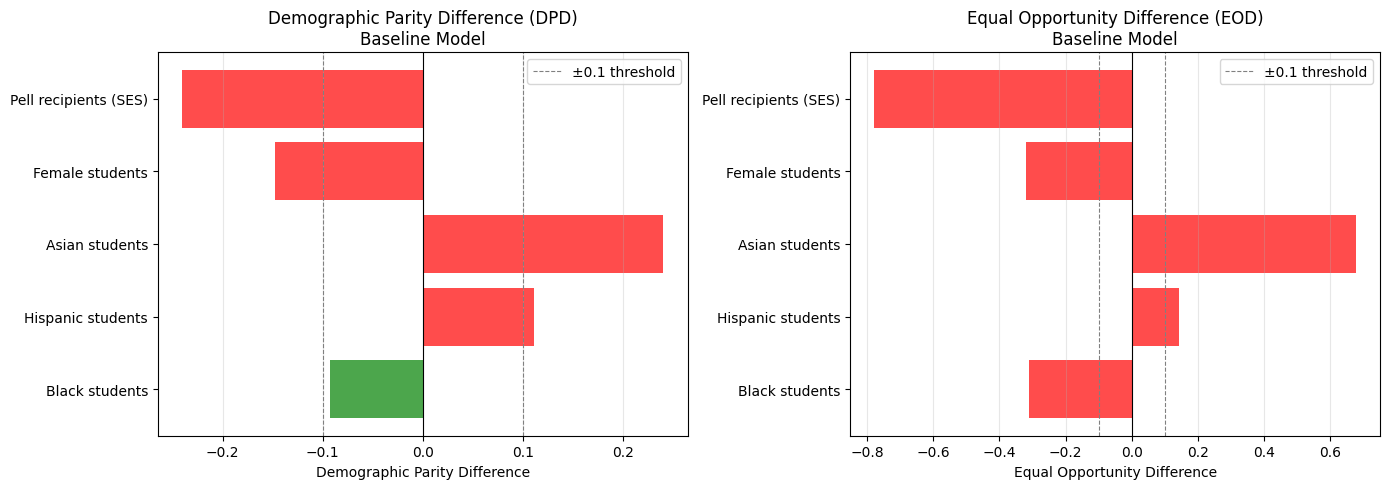


✓ Saved: baseline_fairness_metrics.png


In [8]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Load predictions
DATASET_DIR = "../../resources/datasets/college-scorecard"
df = pd.read_csv(f"{DATASET_DIR}/test_with_baseline_predictions.csv")

# Define fairness metric functions
def demographic_parity_difference(y_true, y_pred, sensitive_attr):
    """Calculate DPD between two groups split by median"""
    median_val = sensitive_attr.median()
    group_a_mask = sensitive_attr >= median_val
    group_b_mask = sensitive_attr < median_val
    
    pr_a = y_pred[group_a_mask].mean()
    pr_b = y_pred[group_b_mask].mean()
    dpd = pr_a - pr_b
    
    return dpd, pr_a, pr_b

def equal_opportunity_difference(y_true, y_pred, sensitive_attr):
    """Calculate EOD (difference in TPR) between two groups"""
    median_val = sensitive_attr.median()
    group_a_mask = sensitive_attr >= median_val
    group_b_mask = sensitive_attr < median_val
    
    y_true_a = y_true[group_a_mask]
    y_pred_a = y_pred[group_a_mask]
    y_true_b = y_true[group_b_mask]
    y_pred_b = y_pred[group_b_mask]
    
    tpr_a = ((y_pred_a == 1) & (y_true_a == 1)).sum() / y_true_a.sum() if y_true_a.sum() > 0 else 0
    tpr_b = ((y_pred_b == 1) & (y_true_b == 1)).sum() / y_true_b.sum() if y_true_b.sum() > 0 else 0
    eod = tpr_a - tpr_b
    
    return eod, tpr_a, tpr_b

# Calculate fairness metrics
sensitive_attrs = {
    'PCT_BLACK': 'Black students',
    'PCT_HISPANIC': 'Hispanic students',
    'PCT_ASIAN': 'Asian students',
    'PCT_FEMALE': 'Female students',
    'PELL_RATE': 'Pell recipients (SES)'
}

results = []

for attr, label in sensitive_attrs.items():
    if attr not in df.columns:
        continue
    
    dpd, pr_high, pr_low = demographic_parity_difference(
        df['SELECTIVE'], df['y_pred'], df[attr]
    )
    eod, tpr_high, tpr_low = equal_opportunity_difference(
        df['SELECTIVE'], df['y_pred'], df[attr]
    )
    
    results.append({
        'Attribute': label,
        'DPD': dpd,
        'DPD_Pass': '✓' if abs(dpd) <= 0.1 else '✗',
        'EOD': eod,
        'EOD_Pass': '✓' if abs(eod) <= 0.1 else '✗'
    })

# Display results
results_df = pd.DataFrame(results)
print("\n" + "="*70)
print("FAIRNESS METRICS - BASELINE MODEL")
print("="*70)
print(results_df.to_string(index=False))
print("\nThreshold: ±0.1 for both DPD and EOD")

# Visualization
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# DPD plot
ax1 = axes[0]
colors = ['green' if abs(x) <= 0.1 else 'red' for x in results_df['DPD']]
ax1.barh(results_df['Attribute'], results_df['DPD'], color=colors, alpha=0.7)
ax1.axvline(0, color='black', linestyle='-', linewidth=0.8)
ax1.axvline(0.1, color='gray', linestyle='--', linewidth=0.8, label='±0.1 threshold')
ax1.axvline(-0.1, color='gray', linestyle='--', linewidth=0.8)
ax1.set_xlabel('Demographic Parity Difference')
ax1.set_title('Demographic Parity Difference (DPD)\nBaseline Model')
ax1.legend()
ax1.grid(axis='x', alpha=0.3)

# EOD plot
ax2 = axes[1]
colors = ['green' if abs(x) <= 0.1 else 'red' for x in results_df['EOD']]
ax2.barh(results_df['Attribute'], results_df['EOD'], color=colors, alpha=0.7)
ax2.axvline(0, color='black', linestyle='-', linewidth=0.8)
ax2.axvline(0.1, color='gray', linestyle='--', linewidth=0.8, label='±0.1 threshold')
ax2.axvline(-0.1, color='gray', linestyle='--', linewidth=0.8)
ax2.set_xlabel('Equal Opportunity Difference')
ax2.set_title('Equal Opportunity Difference (EOD)\nBaseline Model')
ax2.legend()
ax2.grid(axis='x', alpha=0.3)

plt.tight_layout()
plt.savefig(f"{DATASET_DIR}/baseline_fairness_metrics.png", dpi=150, bbox_inches='tight')
plt.show()

print(f"\n✓ Saved: baseline_fairness_metrics.png")

## 4. Fairness-Aware Model (AIDE with ThresholdOptimizer)

AIDE generated a fairness-aware solution using **ThresholdOptimizer** from the fairlearn library with `true_positive_rate_parity` constraint. This approach:
1. Trains a baseline Random Forest classifier
2. Post-processes predictions to equalize True Positive Rates across demographic groups
3. Optimizes group-specific thresholds to achieve Equal Opportunity

In [9]:
import pandas as pd
import numpy as np
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import accuracy_score
from fairlearn.postprocessing import ThresholdOptimizer

# Load data
DATASET_DIR = "../../resources/datasets/college-scorecard"
train = pd.read_csv(f"{DATASET_DIR}/train.csv")
test = pd.read_csv(f"{DATASET_DIR}/test.csv")

# Define sensitive attributes for fairness optimization
sensitive = ["PELL_RATE", "PCT_FEMALE", "PCT_WHITE"]
all_sens = ["PELL_RATE", "PCT_FEMALE", "PCT_ASIAN", "PCT_BLACK", "PCT_HISPANIC", "PCT_WHITE"]
target = "SELECTIVE"

# Prepare features (removing ALL sensitive attributes from model input)
X_train = train.drop(columns=all_sens + [target])
y_train = train[target].values
X_train_sens = train[all_sens]

X_test = test.drop(columns=all_sens + [target])
y_test = test[target].values
X_test_sens = test[all_sens]

print(f"Features used: {X_train.columns.tolist()}")
print(f"Removed sensitive attributes: {all_sens}")

# Helper function to create composite group labels
def make_group(df_sens, medians):
    """Create composite group ID from three sensitive attributes"""
    grp = (
        (df_sens["PELL_RATE"] >= medians[0]).astype(int).astype(str) +
        (df_sens["PCT_FEMALE"] >= medians[1]).astype(int).astype(str) +
        (df_sens["PCT_WHITE"] >= medians[2]).astype(int).astype(str)
    )
    return grp.values

# One-hot encode categorical variables
full = pd.concat([X_train, X_test], axis=0)
full_enc = pd.get_dummies(full, columns=["LOCALE", "PREDOMINANT_DEGREE"], drop_first=True)

X_train_enc = full_enc.iloc[:len(X_train), :].reset_index(drop=True)
X_test_enc = full_enc.iloc[len(X_train):, :].reset_index(drop=True)

print(f"Encoded features: {X_train_enc.shape[1]} columns")

# Cross-validation with fairness evaluation
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
accs = []
eods = []

print("\nCross-validation with fairness optimization...")
for fold_idx, (train_idx, val_idx) in enumerate(skf.split(X_train_enc, y_train), 1):
    X_tr, X_val = X_train_enc.iloc[train_idx], X_train_enc.iloc[val_idx]
    y_tr, y_val = y_train[train_idx], y_train[val_idx]
    sens_tr = X_train_sens.iloc[train_idx][sensitive]
    sens_val = X_train_sens.iloc[val_idx][sensitive]
    
    # Compute medians on training fold
    meds = [sens_tr[col].median() for col in sensitive]
    grp_tr = make_group(sens_tr, meds)
    grp_val = make_group(sens_val, meds)
    
    # Train base classifier
    clf = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
    clf.fit(X_tr, y_tr)
    
    # Post-process for Equal Opportunity via ThresholdOptimizer
    thr = ThresholdOptimizer(
        estimator=clf,
        constraints="true_positive_rate_parity",
        prefit=True,
        predict_method="predict_proba",
    )
    thr.fit(X_tr, y_tr, sensitive_features=grp_tr)
    y_pred = thr.predict(X_val, sensitive_features=grp_val)
    
    accs.append(accuracy_score(y_val, y_pred))
    
    # Compute EOD on each sensitive attribute separately
    eod_fold = 0.0
    for attr in sensitive:
        med = sens_tr[attr].median()
        high = sens_val[attr] >= med
        low = sens_val[attr] < med
        
        def tpr(mask):
            denom = np.sum((y_val == 1) & mask)
            if denom == 0:
                return 0.0
            return np.sum((y_pred == 1) & (y_val == 1) & mask) / denom
        
        diff = abs(tpr(high) - tpr(low))
        eod_fold = max(eod_fold, diff)
    
    eods.append(eod_fold)
    print(f"Fold {fold_idx}: Acc={accs[-1]:.4f}, EOD={eods[-1]:.4f}")

mean_acc = np.mean(accs)
mean_eod = np.mean(eods)
print(f"\nMean CV Accuracy: {mean_acc:.4f}")
print(f"Mean CV EOD: {mean_eod:.4f}")

# Retrain on full training data and predict test set
meds_full = [train[col].median() for col in sensitive]
grp_full = make_group(train[sensitive], meds_full)
grp_test = make_group(test[sensitive], meds_full)

clf_full = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
clf_full.fit(X_train_enc, y_train)

thr_full = ThresholdOptimizer(
    estimator=clf_full,
    constraints="true_positive_rate_parity",
    prefit=True,
    predict_method="predict_proba",
)
thr_full.fit(X_train_enc, y_train, sensitive_features=grp_full)
y_pred_fair = thr_full.predict(X_test_enc, sensitive_features=grp_test)
y_pred_proba_fair = clf_full.predict_proba(X_test_enc)[:, 1]

# Save predictions
test_with_predictions = test.copy()
test_with_predictions['y_pred'] = y_pred_fair
test_with_predictions['y_pred_proba'] = y_pred_proba_fair
test_with_predictions.to_csv(f"{DATASET_DIR}/test_with_fairness_predictions.csv", index=False)

print(f"✓ Fairness predictions saved to test_with_fairness_predictions.csv")

Features used: ['SAT_AVG', 'STUDENT_SIZE', 'TUITION', 'COMPLETION_RATE', 'PREDOMINANT_DEGREE', 'LOCALE']
Removed sensitive attributes: ['PELL_RATE', 'PCT_FEMALE', 'PCT_ASIAN', 'PCT_BLACK', 'PCT_HISPANIC', 'PCT_WHITE']
Encoded features: 17 columns

Cross-validation with fairness optimization...
Fold 1: Acc=0.9070, EOD=0.6368
Fold 2: Acc=0.9186, EOD=0.8400
Fold 3: Acc=0.9244, EOD=0.7826
Fold 4: Acc=0.8953, EOD=0.5682
Fold 5: Acc=0.9128, EOD=0.7917

Mean CV Accuracy: 0.9116
Mean CV EOD: 0.7239
✓ Fairness predictions saved to test_with_fairness_predictions.csv


## 5. Fairness Model Evaluation

Evaluating the fairness-aware model using the same metrics as the baseline to compare improvements.


FAIRNESS METRICS - FAIRNESS-AWARE MODEL
            Attribute       DPD DPD_Pass       EOD EOD_Pass
       Black students -0.074074        ✓ -0.094444        ✓
    Hispanic students  0.129630        ✗  0.210728        ✗
       Asian students  0.203704        ✗  0.391705        ✗
      Female students -0.166667        ✗ -0.519231        ✗
Pell recipients (SES) -0.222222        ✗ -0.595960        ✗

Threshold: ±0.1 for both DPD and EOD

Test Accuracy: 0.8981


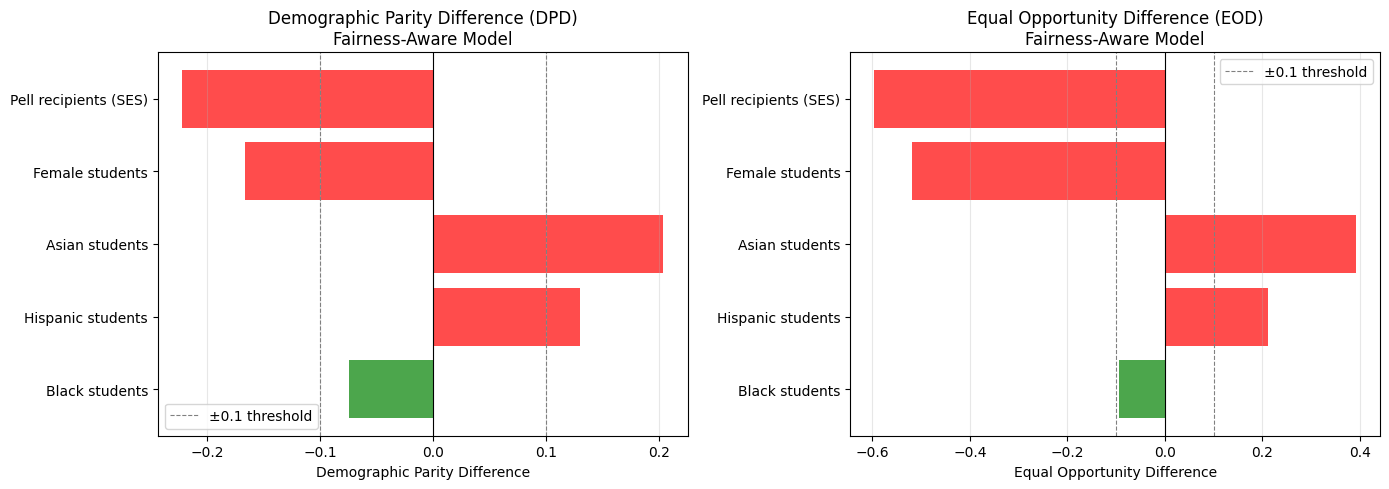


✓ Saved: fairness_aware_metrics.png


In [10]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Load fairness predictions
DATASET_DIR = "../../resources/datasets/college-scorecard"
df_fair = pd.read_csv(f"{DATASET_DIR}/test_with_fairness_predictions.csv")

# Reuse fairness metric functions from baseline analysis
def demographic_parity_difference(y_true, y_pred, sensitive_attr):
    median_val = sensitive_attr.median()
    group_a_mask = sensitive_attr >= median_val
    group_b_mask = sensitive_attr < median_val
    pr_a = y_pred[group_a_mask].mean()
    pr_b = y_pred[group_b_mask].mean()
    return pr_a - pr_b

def equal_opportunity_difference(y_true, y_pred, sensitive_attr):
    median_val = sensitive_attr.median()
    group_a_mask = sensitive_attr >= median_val
    group_b_mask = sensitive_attr < median_val
    y_true_a = y_true[group_a_mask]
    y_pred_a = y_pred[group_a_mask]
    y_true_b = y_true[group_b_mask]
    y_pred_b = y_pred[group_b_mask]
    tpr_a = ((y_pred_a == 1) & (y_true_a == 1)).sum() / y_true_a.sum() if y_true_a.sum() > 0 else 0
    tpr_b = ((y_pred_b == 1) & (y_true_b == 1)).sum() / y_true_b.sum() if y_true_b.sum() > 0 else 0
    return tpr_a - tpr_b

# Calculate fairness metrics
sensitive_attrs = {
    'PCT_BLACK': 'Black students',
    'PCT_HISPANIC': 'Hispanic students',
    'PCT_ASIAN': 'Asian students',
    'PCT_FEMALE': 'Female students',
    'PELL_RATE': 'Pell recipients (SES)'
}

results_fair = []
for attr, label in sensitive_attrs.items():
    dpd = demographic_parity_difference(df_fair['SELECTIVE'], df_fair['y_pred'], df_fair[attr])
    eod = equal_opportunity_difference(df_fair['SELECTIVE'], df_fair['y_pred'], df_fair[attr])
    results_fair.append({
        'Attribute': label,
        'DPD': dpd,
        'DPD_Pass': '✓' if abs(dpd) <= 0.1 else '✗',
        'EOD': eod,
        'EOD_Pass': '✓' if abs(eod) <= 0.1 else '✗'
    })

# Display results
results_fair_df = pd.DataFrame(results_fair)
print("\n" + "="*70)
print("FAIRNESS METRICS - FAIRNESS-AWARE MODEL")
print("="*70)
print(results_fair_df.to_string(index=False))
print("\nThreshold: ±0.1 for both DPD and EOD")

# Test accuracy
test_accuracy = (df_fair['y_pred'] == df_fair['SELECTIVE']).mean()
print(f"\nTest Accuracy: {test_accuracy:.4f}")

# Visualization
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# DPD plot
ax1 = axes[0]
colors = ['green' if abs(x) <= 0.1 else 'red' for x in results_fair_df['DPD']]
ax1.barh(results_fair_df['Attribute'], results_fair_df['DPD'], color=colors, alpha=0.7)
ax1.axvline(0, color='black', linestyle='-', linewidth=0.8)
ax1.axvline(0.1, color='gray', linestyle='--', linewidth=0.8, label='±0.1 threshold')
ax1.axvline(-0.1, color='gray', linestyle='--', linewidth=0.8)
ax1.set_xlabel('Demographic Parity Difference')
ax1.set_title('Demographic Parity Difference (DPD)\nFairness-Aware Model')
ax1.legend()
ax1.grid(axis='x', alpha=0.3)

# EOD plot
ax2 = axes[1]
colors = ['green' if abs(x) <= 0.1 else 'red' for x in results_fair_df['EOD']]
ax2.barh(results_fair_df['Attribute'], results_fair_df['EOD'], color=colors, alpha=0.7)
ax2.axvline(0, color='black', linestyle='-', linewidth=0.8)
ax2.axvline(0.1, color='gray', linestyle='--', linewidth=0.8, label='±0.1 threshold')
ax2.axvline(-0.1, color='gray', linestyle='--', linewidth=0.8)
ax2.set_xlabel('Equal Opportunity Difference')
ax2.set_title('Equal Opportunity Difference (EOD)\nFairness-Aware Model')
ax2.legend()
ax2.grid(axis='x', alpha=0.3)

plt.tight_layout()
plt.savefig(f"{DATASET_DIR}/fairness_aware_metrics.png", dpi=150, bbox_inches='tight')
plt.show()

print(f"\n✓ Saved: fairness_aware_metrics.png")

## 6. Baseline vs Fairness-Aware Comparison

Comparing the two models to assess the accuracy-fairness trade-off.


MODEL COMPARISON: BASELINE vs FAIRNESS-AWARE

Accuracy:
  Baseline:       0.8981
  Fairness-Aware: 0.8981
  Change:         +0.0000

Demographic Parity Difference (DPD):
------------------------------------------------------------------------------------------
            Attribute  Baseline_DPD  Fair_DPD  DPD_Improvement
       Black students     -0.092593 -0.074074        -0.018519
    Hispanic students      0.111111  0.129630        -0.018519
       Asian students      0.240741  0.203704         0.037037
      Female students     -0.148148 -0.166667         0.018519
Pell recipients (SES)     -0.240741 -0.222222        -0.018519

Equal Opportunity Difference (EOD):
------------------------------------------------------------------------------------------
            Attribute  Baseline_EOD  Fair_EOD  EOD_Improvement
       Black students     -0.311111 -0.094444        -0.216667
    Hispanic students      0.141762  0.210728        -0.068966
       Asian students      0.677419  0.3917

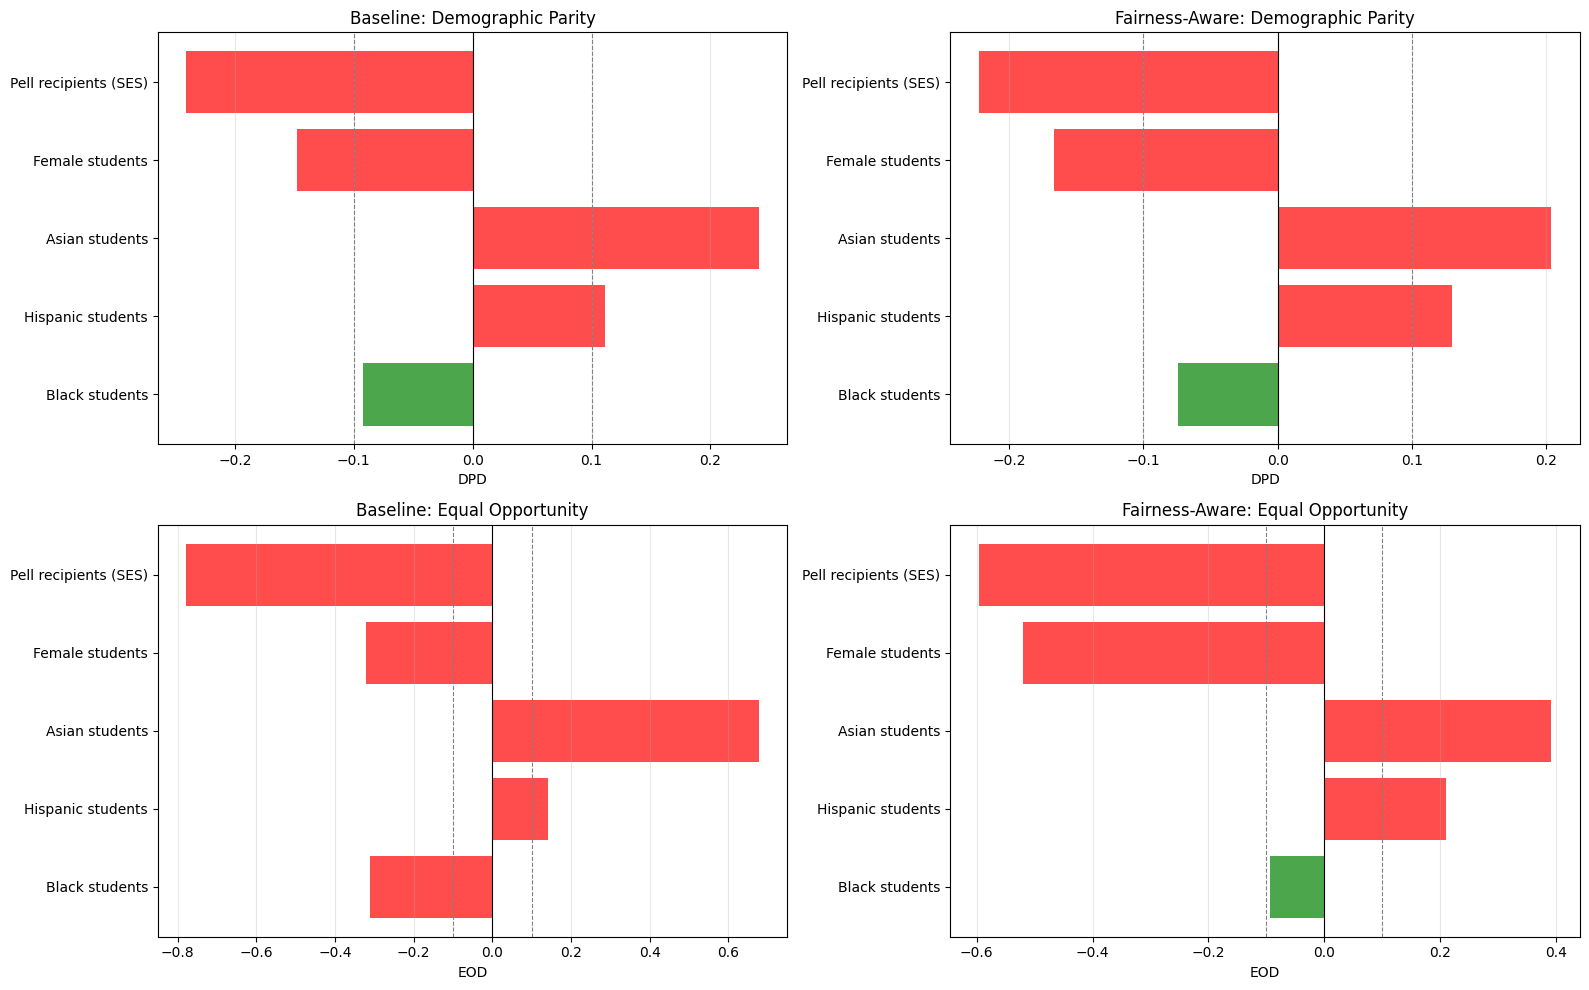


✓ Saved: baseline_vs_fairness_comparison.png


In [11]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Load both predictions
DATASET_DIR = "../../resources/datasets/college-scorecard"
df_baseline = pd.read_csv(f"{DATASET_DIR}/test_with_baseline_predictions.csv")
df_fair = pd.read_csv(f"{DATASET_DIR}/test_with_fairness_predictions.csv")

# Calculate metrics for both models
sensitive_attrs = {
    'PCT_BLACK': 'Black students',
    'PCT_HISPANIC': 'Hispanic students',
    'PCT_ASIAN': 'Asian students',
    'PCT_FEMALE': 'Female students',
    'PELL_RATE': 'Pell recipients (SES)'
}

def calculate_metrics(df, y_true_col='SELECTIVE', y_pred_col='y_pred'):
    def dpd(attr):
        median = df[attr].median()
        high = df[attr] >= median
        low = df[attr] < median
        return df[y_pred_col][high].mean() - df[y_pred_col][low].mean()
    
    def eod(attr):
        median = df[attr].median()
        high = df[attr] >= median
        low = df[attr] < median
        y_true = df[y_true_col]
        y_pred = df[y_pred_col]
        tpr_high = ((y_pred[high] == 1) & (y_true[high] == 1)).sum() / y_true[high].sum() if y_true[high].sum() > 0 else 0
        tpr_low = ((y_pred[low] == 1) & (y_true[low] == 1)).sum() / y_true[low].sum() if y_true[low].sum() > 0 else 0
        return tpr_high - tpr_low
    
    metrics = {}
    for attr in sensitive_attrs.keys():
        metrics[attr] = {
            'DPD': dpd(attr),
            'EOD': eod(attr)
        }
    
    accuracy = (df[y_pred_col] == df[y_true_col]).mean()
    return metrics, accuracy

baseline_metrics, baseline_acc = calculate_metrics(df_baseline)
fair_metrics, fair_acc = calculate_metrics(df_fair)

# Create comparison table
comparison_data = []
for attr, label in sensitive_attrs.items():
    comparison_data.append({
        'Attribute': label,
        'Baseline_DPD': baseline_metrics[attr]['DPD'],
        'Fair_DPD': fair_metrics[attr]['DPD'],
        'DPD_Improvement': baseline_metrics[attr]['DPD'] - fair_metrics[attr]['DPD'],
        'Baseline_EOD': baseline_metrics[attr]['EOD'],
        'Fair_EOD': fair_metrics[attr]['EOD'],
        'EOD_Improvement': baseline_metrics[attr]['EOD'] - fair_metrics[attr]['EOD']
    })

comparison_df = pd.DataFrame(comparison_data)

print("\n" + "="*90)
print("MODEL COMPARISON: BASELINE vs FAIRNESS-AWARE")
print("="*90)
print(f"\nAccuracy:")
print(f"  Baseline:       {baseline_acc:.4f}")
print(f"  Fairness-Aware: {fair_acc:.4f}")
print(f"  Change:         {fair_acc - baseline_acc:+.4f}")

print(f"\nDemographic Parity Difference (DPD):")
print("-" * 90)
print(comparison_df[['Attribute', 'Baseline_DPD', 'Fair_DPD', 'DPD_Improvement']].to_string(index=False))

print(f"\nEqual Opportunity Difference (EOD):")
print("-" * 90)
print(comparison_df[['Attribute', 'Baseline_EOD', 'Fair_EOD', 'EOD_Improvement']].to_string(index=False))

# Count passing metrics
def count_pass(metrics, threshold=0.1):
    dpd_pass = sum(1 for m in metrics.values() if abs(m['DPD']) <= threshold)
    eod_pass = sum(1 for m in metrics.values() if abs(m['EOD']) <= threshold)
    return dpd_pass, eod_pass

baseline_dpd_pass, baseline_eod_pass = count_pass(baseline_metrics)
fair_dpd_pass, fair_eod_pass = count_pass(fair_metrics)

print(f"\nMetrics Passing ±0.1 Threshold:")
print(f"  Baseline:       DPD={baseline_dpd_pass}/5, EOD={baseline_eod_pass}/5, Total={baseline_dpd_pass + baseline_eod_pass}/10")
print(f"  Fairness-Aware: DPD={fair_dpd_pass}/5, EOD={fair_eod_pass}/5, Total={fair_dpd_pass + fair_eod_pass}/10")
print(f"  Improvement:    +{(fair_dpd_pass + fair_eod_pass) - (baseline_dpd_pass + baseline_eod_pass)} passing metrics")

# Visualization - Side by side comparison
fig, axes = plt.subplots(2, 2, figsize=(16, 10))

attrs_labels = [sensitive_attrs[k] for k in sensitive_attrs.keys()]
baseline_dpd_vals = [baseline_metrics[k]['DPD'] for k in sensitive_attrs.keys()]
fair_dpd_vals = [fair_metrics[k]['DPD'] for k in sensitive_attrs.keys()]
baseline_eod_vals = [baseline_metrics[k]['EOD'] for k in sensitive_attrs.keys()]
fair_eod_vals = [fair_metrics[k]['EOD'] for k in sensitive_attrs.keys()]

# Baseline DPD
ax = axes[0, 0]
colors = ['red' if abs(x) > 0.1 else 'green' for x in baseline_dpd_vals]
ax.barh(attrs_labels, baseline_dpd_vals, color=colors, alpha=0.7)
ax.axvline(0, color='black', linewidth=0.8)
ax.axvline(0.1, color='gray', linestyle='--', linewidth=0.8)
ax.axvline(-0.1, color='gray', linestyle='--', linewidth=0.8)
ax.set_xlabel('DPD')
ax.set_title('Baseline: Demographic Parity')
ax.grid(axis='x', alpha=0.3)

# Fairness-Aware DPD
ax = axes[0, 1]
colors = ['red' if abs(x) > 0.1 else 'green' for x in fair_dpd_vals]
ax.barh(attrs_labels, fair_dpd_vals, color=colors, alpha=0.7)
ax.axvline(0, color='black', linewidth=0.8)
ax.axvline(0.1, color='gray', linestyle='--', linewidth=0.8)
ax.axvline(-0.1, color='gray', linestyle='--', linewidth=0.8)
ax.set_xlabel('DPD')
ax.set_title('Fairness-Aware: Demographic Parity')
ax.grid(axis='x', alpha=0.3)

# Baseline EOD
ax = axes[1, 0]
colors = ['red' if abs(x) > 0.1 else 'green' for x in baseline_eod_vals]
ax.barh(attrs_labels, baseline_eod_vals, color=colors, alpha=0.7)
ax.axvline(0, color='black', linewidth=0.8)
ax.axvline(0.1, color='gray', linestyle='--', linewidth=0.8)
ax.axvline(-0.1, color='gray', linestyle='--', linewidth=0.8)
ax.set_xlabel('EOD')
ax.set_title('Baseline: Equal Opportunity')
ax.grid(axis='x', alpha=0.3)

# Fairness-Aware EOD
ax = axes[1, 1]
colors = ['red' if abs(x) > 0.1 else 'green' for x in fair_eod_vals]
ax.barh(attrs_labels, fair_eod_vals, color=colors, alpha=0.7)
ax.axvline(0, color='black', linewidth=0.8)
ax.axvline(0.1, color='gray', linestyle='--', linewidth=0.8)
ax.axvline(-0.1, color='gray', linestyle='--', linewidth=0.8)
ax.set_xlabel('EOD')
ax.set_title('Fairness-Aware: Equal Opportunity')
ax.grid(axis='x', alpha=0.3)

plt.tight_layout()
plt.savefig(f"{DATASET_DIR}/baseline_vs_fairness_comparison.png", dpi=150, bbox_inches='tight')
plt.show()

print(f"\n✓ Saved: baseline_vs_fairness_comparison.png")

## 7. Alternative Approach: Unawareness (Feature Removal Only)

The simplest fairness intervention: train the model without any sensitive attributes. No post-processing, no threshold optimization - just remove the features that encode demographic information.

In [12]:
import pandas as pd
import numpy as np
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import StratifiedKFold, cross_val_score

# Load data
DATASET_DIR = "../../resources/datasets/college-scorecard"
train = pd.read_csv(f"{DATASET_DIR}/train.csv")
test = pd.read_csv(f"{DATASET_DIR}/test.csv")

# Remove ALL sensitive attributes
sensitive_attrs = ["PELL_RATE", "PCT_FEMALE", "PCT_ASIAN", "PCT_BLACK", "PCT_HISPANIC", "PCT_WHITE"]
X_train_unaware = train.drop(columns=sensitive_attrs + ["SELECTIVE"])
y_train = train["SELECTIVE"]
X_test_unaware = test.drop(columns=sensitive_attrs + ["SELECTIVE"])
y_test = test["SELECTIVE"]

print(f"Original features: {train.drop(columns=['SELECTIVE']).shape[1]}")
print(f"Unawareness features: {X_train_unaware.shape[1]}")
print(f"Removed: {sensitive_attrs}")

# One-hot encode categorical variables
full = pd.concat([X_train_unaware, X_test_unaware], axis=0)
full_enc = pd.get_dummies(full, columns=["LOCALE", "PREDOMINANT_DEGREE"], drop_first=True)

X_train_enc = full_enc.iloc[:len(X_train_unaware), :].reset_index(drop=True)
X_test_enc = full_enc.iloc[len(X_train_unaware):, :].reset_index(drop=True)

print(f"Encoded features: {X_train_enc.shape[1]} columns")

# Train model
rf_unaware = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)

# Cross-validation
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
cv_scores = cross_val_score(rf_unaware, X_train_enc, y_train, cv=skf, scoring="accuracy", n_jobs=-1)
print(f"\nMean CV Accuracy: {cv_scores.mean():.4f}")

# Train on full data and predict
rf_unaware.fit(X_train_enc, y_train)
y_pred_unaware = rf_unaware.predict(X_test_enc)
y_pred_proba_unaware = rf_unaware.predict_proba(X_test_enc)[:, 1]

test_acc = (y_pred_unaware == y_test).mean()
print(f"Test Accuracy: {test_acc:.4f}")

# Save predictions
test_with_predictions = test.copy()
test_with_predictions['y_pred'] = y_pred_unaware
test_with_predictions['y_pred_proba'] = y_pred_proba_unaware
test_with_predictions.to_csv(f"{DATASET_DIR}/test_with_unawareness_predictions.csv", index=False)

print(f"✓ Predictions saved to test_with_unawareness_predictions.csv")

Original features: 12
Unawareness features: 6
Removed: ['PELL_RATE', 'PCT_FEMALE', 'PCT_ASIAN', 'PCT_BLACK', 'PCT_HISPANIC', 'PCT_WHITE']
Encoded features: 17 columns

Mean CV Accuracy: 0.9151
Test Accuracy: 0.9074
✓ Predictions saved to test_with_unawareness_predictions.csv



FAIRNESS METRICS - UNAWARENESS MODEL
            Attribute       DPD DPD_Pass       EOD EOD_Pass
       Black students -0.055556        ✓ -0.150000        ✗
    Hispanic students  0.129630        ✗  0.176245        ✗
       Asian students  0.222222        ✗  0.534562        ✗
      Female students -0.166667        ✗ -0.480769        ✗
Pell recipients (SES) -0.222222        ✗ -0.686869        ✗

Threshold: ±0.1 for both DPD and EOD

Test Accuracy: 0.9074
Passing metrics: DPD=1/5, EOD=0/5, Total=1/10


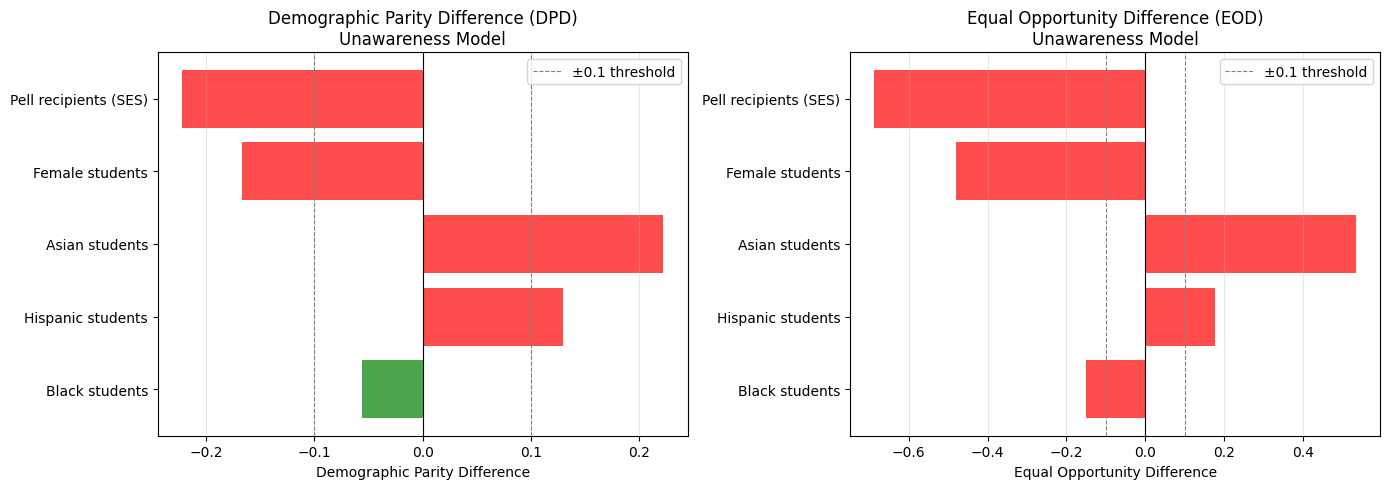


✓ Saved: unawareness_metrics.png


In [13]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Load unawareness predictions
DATASET_DIR = "../../resources/datasets/college-scorecard"
df_unaware = pd.read_csv(f"{DATASET_DIR}/test_with_unawareness_predictions.csv")

# Calculate fairness metrics
def demographic_parity_difference(y_true, y_pred, sensitive_attr):
    median_val = sensitive_attr.median()
    group_a_mask = sensitive_attr >= median_val
    group_b_mask = sensitive_attr < median_val
    pr_a = y_pred[group_a_mask].mean()
    pr_b = y_pred[group_b_mask].mean()
    return pr_a - pr_b

def equal_opportunity_difference(y_true, y_pred, sensitive_attr):
    median_val = sensitive_attr.median()
    group_a_mask = sensitive_attr >= median_val
    group_b_mask = sensitive_attr < median_val
    y_true_a = y_true[group_a_mask]
    y_pred_a = y_pred[group_a_mask]
    y_true_b = y_true[group_b_mask]
    y_pred_b = y_pred[group_b_mask]
    tpr_a = ((y_pred_a == 1) & (y_true_a == 1)).sum() / y_true_a.sum() if y_true_a.sum() > 0 else 0
    tpr_b = ((y_pred_b == 1) & (y_true_b == 1)).sum() / y_true_b.sum() if y_true_b.sum() > 0 else 0
    return tpr_a - tpr_b

sensitive_attrs = {
    'PCT_BLACK': 'Black students',
    'PCT_HISPANIC': 'Hispanic students',
    'PCT_ASIAN': 'Asian students',
    'PCT_FEMALE': 'Female students',
    'PELL_RATE': 'Pell recipients (SES)'
}

results_unaware = []
for attr, label in sensitive_attrs.items():
    dpd = demographic_parity_difference(df_unaware['SELECTIVE'], df_unaware['y_pred'], df_unaware[attr])
    eod = equal_opportunity_difference(df_unaware['SELECTIVE'], df_unaware['y_pred'], df_unaware[attr])
    results_unaware.append({
        'Attribute': label,
        'DPD': dpd,
        'DPD_Pass': '✓' if abs(dpd) <= 0.1 else '✗',
        'EOD': eod,
        'EOD_Pass': '✓' if abs(eod) <= 0.1 else '✗'
    })

results_unaware_df = pd.DataFrame(results_unaware)

print("\n" + "="*70)
print("FAIRNESS METRICS - UNAWARENESS MODEL")
print("="*70)
print(results_unaware_df.to_string(index=False))
print("\nThreshold: ±0.1 for both DPD and EOD")

test_accuracy = (df_unaware['y_pred'] == df_unaware['SELECTIVE']).mean()
print(f"\nTest Accuracy: {test_accuracy:.4f}")

# Count passing metrics
dpd_pass = sum(1 for _, row in results_unaware_df.iterrows() if abs(row['DPD']) <= 0.1)
eod_pass = sum(1 for _, row in results_unaware_df.iterrows() if abs(row['EOD']) <= 0.1)
print(f"Passing metrics: DPD={dpd_pass}/5, EOD={eod_pass}/5, Total={dpd_pass + eod_pass}/10")

# Visualization
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# DPD plot
ax1 = axes[0]
colors = ['green' if abs(x) <= 0.1 else 'red' for x in results_unaware_df['DPD']]
ax1.barh(results_unaware_df['Attribute'], results_unaware_df['DPD'], color=colors, alpha=0.7)
ax1.axvline(0, color='black', linestyle='-', linewidth=0.8)
ax1.axvline(0.1, color='gray', linestyle='--', linewidth=0.8, label='±0.1 threshold')
ax1.axvline(-0.1, color='gray', linestyle='--', linewidth=0.8)
ax1.set_xlabel('Demographic Parity Difference')
ax1.set_title('Demographic Parity Difference (DPD)\nUnawareness Model')
ax1.legend()
ax1.grid(axis='x', alpha=0.3)

# EOD plot
ax2 = axes[1]
colors = ['green' if abs(x) <= 0.1 else 'red' for x in results_unaware_df['EOD']]
ax2.barh(results_unaware_df['Attribute'], results_unaware_df['EOD'], color=colors, alpha=0.7)
ax2.axvline(0, color='black', linestyle='-', linewidth=0.8)
ax2.axvline(0.1, color='gray', linestyle='--', linewidth=0.8, label='±0.1 threshold')
ax2.axvline(-0.1, color='gray', linestyle='--', linewidth=0.8)
ax2.set_xlabel('Equal Opportunity Difference')
ax2.set_title('Equal Opportunity Difference (EOD)\nUnawareness Model')
ax2.legend()
ax2.grid(axis='x', alpha=0.3)

plt.tight_layout()
plt.savefig(f"{DATASET_DIR}/unawareness_metrics.png", dpi=150, bbox_inches='tight')
plt.show()

print(f"\n✓ Saved: unawareness_metrics.png")

## 8. Alternative Approach: Exponentiated Gradient Reduction

An **in-processing** fairness technique that incorporates fairness constraints directly into the model training process. Unlike post-processing methods (ThresholdOptimizer), this approach trains the model while simultaneously optimizing for fairness.

**Key Features:**
- Uses a reduction approach to convert fairness-constrained learning into a sequence of cost-sensitive classification problems
- Optimizes for Equalized Odds (both TPR and FPR parity across groups)
- More flexible than post-processing as it modifies the learning process itself

In [15]:
import pandas as pd
import numpy as np
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import accuracy_score
from fairlearn.reductions import ExponentiatedGradient, EqualizedOdds

# Load data
DATASET_DIR = "../../resources/datasets/college-scorecard"
train = pd.read_csv(f"{DATASET_DIR}/train.csv")
test = pd.read_csv(f"{DATASET_DIR}/test.csv")

# Define sensitive attributes (same as ThresholdOptimizer for consistency)
sensitive_list = ["PELL_RATE", "PCT_FEMALE", "PCT_WHITE"]
target = "SELECTIVE"

# Prepare features (keep all features including sensitive ones for in-processing)
X_train = train.drop(columns=[target])
y_train = train[target].values

X_test = test.drop(columns=[target])
y_test = test[target].values

print(f"Features used: {X_train.shape[1]} columns (including sensitive attributes)")

# One-hot encode categorical variables
full = pd.concat([X_train, X_test], axis=0)
full_enc = pd.get_dummies(full, columns=["LOCALE", "PREDOMINANT_DEGREE"], drop_first=True)

X_train_enc = full_enc.iloc[:len(X_train), :].reset_index(drop=True)
X_test_enc = full_enc.iloc[len(X_train):, :].reset_index(drop=True)

print(f"Encoded features: {X_train_enc.shape[1]} columns")

# Helper function for composite group labels
def make_group(df_sens, medians):
    """Create composite group ID from three sensitive attributes"""
    grp = (
        (df_sens["PELL_RATE"] >= medians[0]).astype(int).astype(str) +
        (df_sens["PCT_FEMALE"] >= medians[1]).astype(int).astype(str) +
        (df_sens["PCT_WHITE"] >= medians[2]).astype(int).astype(str)
    )
    return grp.values

print("\nTraining with Exponentiated Gradient Reduction...")
print("This may take 2-3 minutes due to iterative fairness optimization...")

# Cross-validation
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
accs = []
eods = []

for fold_idx, (train_idx, val_idx) in enumerate(skf.split(X_train_enc, y_train), 1):
    X_tr, X_val = X_train_enc.iloc[train_idx], X_train_enc.iloc[val_idx]
    y_tr, y_val = y_train[train_idx], y_train[val_idx]
    sens_tr = train[sensitive_list].iloc[train_idx]
    sens_val = train[sensitive_list].iloc[val_idx]
    
    # Compute medians on training fold
    meds = [sens_tr[col].median() for col in sensitive_list]
    grp_tr = make_group(sens_tr, meds)
    grp_val = make_group(sens_val, meds)
    
    # Train with fairness constraints
    clf = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
    mitigator = ExponentiatedGradient(
        estimator=clf,
        constraints=EqualizedOdds(),
        max_iter=50,
        eps=0.01
    )
    
    mitigator.fit(X_tr, y_tr, sensitive_features=grp_tr)
    y_pred = mitigator.predict(X_val)
    
    accs.append(accuracy_score(y_val, y_pred))
    
    # Compute EOD
    eod_fold = 0.0
    for attr in sensitive_list:
        med = sens_tr[attr].median()
        high = sens_val[attr] >= med
        low = sens_val[attr] < med
        
        def tpr(mask):
            denom = np.sum((y_val == 1) & mask)
            if denom == 0:
                return 0.0
            return np.sum((y_pred == 1) & (y_val == 1) & mask) / denom
        
        diff = abs(tpr(high) - tpr(low))
        eod_fold = max(eod_fold, diff)
    
    eods.append(eod_fold)
    print(f"Fold {fold_idx}: Acc={accs[-1]:.4f}, EOD={eods[-1]:.4f}")

print(f"\nMean CV Accuracy: {np.mean(accs):.4f}")
print(f"Mean CV EOD: {np.mean(eods):.4f}")

# Train on full training data
meds_full = [train[col].median() for col in sensitive_list]
grp_full = make_group(train[sensitive_list], meds_full)
grp_test = make_group(test[sensitive_list], meds_full)

clf_full = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
exp_grad = ExponentiatedGradient(
    estimator=clf_full,
    constraints=EqualizedOdds(),
    eps=0.01,
    max_iter=50
)

exp_grad.fit(X_train_enc, y_train, sensitive_features=grp_full)
y_pred_expgrad = exp_grad.predict(X_test_enc)

test_acc = (y_pred_expgrad == y_test).mean()
print(f"\nTest Accuracy: {test_acc:.4f}")

# Save predictions
test_with_predictions = test.copy()
test_with_predictions['y_pred'] = y_pred_expgrad
test_with_predictions.to_csv(f"{DATASET_DIR}/test_with_expgrad_predictions.csv", index=False)

print(f"✓ Predictions saved to test_with_expgrad_predictions.csv")

Features used: 12 columns (including sensitive attributes)
Encoded features: 23 columns

Training with Exponentiated Gradient Reduction...
This may take 2-3 minutes due to iterative fairness optimization...
Fold 1: Acc=0.9012, EOD=0.7368
Fold 2: Acc=0.9186, EOD=0.7200
Fold 3: Acc=0.9186, EOD=0.7391
Fold 4: Acc=0.9128, EOD=0.6477
Fold 5: Acc=0.9012, EOD=0.7500

Mean CV Accuracy: 0.9105
Mean CV EOD: 0.7187

Test Accuracy: 0.8981
✓ Predictions saved to test_with_expgrad_predictions.csv



FAIRNESS METRICS - EXPONENTIATED GRADIENT MODEL
            Attribute       DPD DPD_Pass       EOD EOD_Pass
       Black students -0.092593        ✓ -0.311111        ✗
    Hispanic students  0.111111        ✗  0.141762        ✗
       Asian students  0.240741        ✗  0.677419        ✗
      Female students -0.148148        ✗ -0.320513        ✗
Pell recipients (SES) -0.240741        ✗ -0.777778        ✗

Threshold: ±0.1 for both DPD and EOD

Test Accuracy: 0.8981
Passing metrics: DPD=1/5, EOD=0/5, Total=1/10


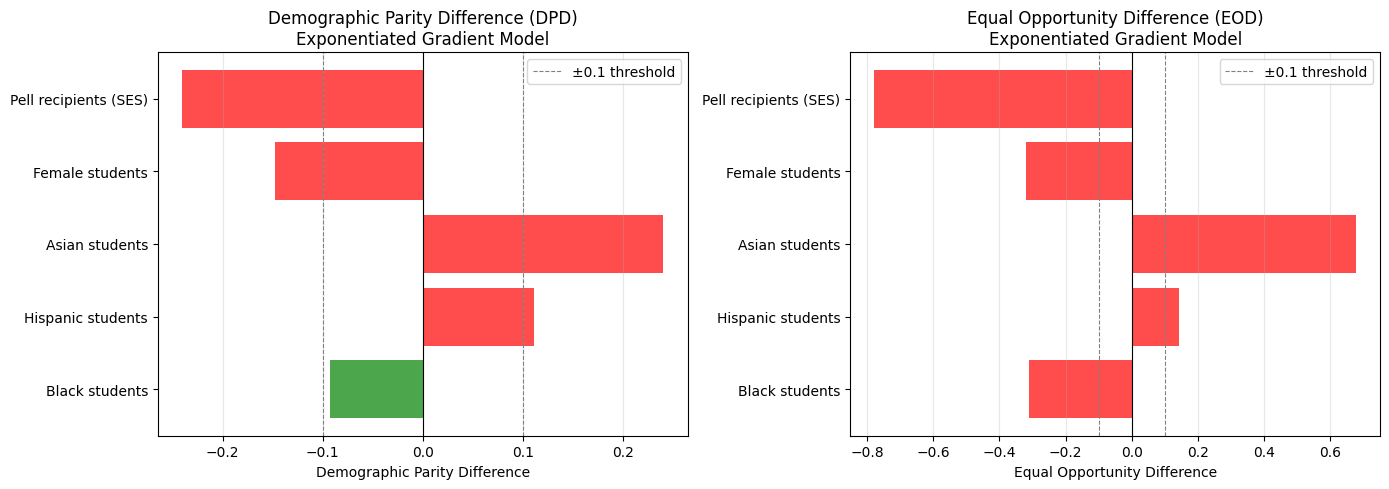


✓ Saved: expgrad_metrics.png


In [17]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Load Exponentiated Gradient predictions
DATASET_DIR = "../../resources/datasets/college-scorecard"
df_expgrad = pd.read_csv(f"{DATASET_DIR}/test_with_expgrad_predictions.csv")

# Calculate fairness metrics
def demographic_parity_difference(y_true, y_pred, sensitive_attr):
    median_val = sensitive_attr.median()
    group_a_mask = sensitive_attr >= median_val
    group_b_mask = sensitive_attr < median_val
    pr_a = y_pred[group_a_mask].mean()
    pr_b = y_pred[group_b_mask].mean()
    return pr_a - pr_b

def equal_opportunity_difference(y_true, y_pred, sensitive_attr):
    median_val = sensitive_attr.median()
    group_a_mask = sensitive_attr >= median_val
    group_b_mask = sensitive_attr < median_val
    y_true_a = y_true[group_a_mask]
    y_pred_a = y_pred[group_a_mask]
    y_true_b = y_true[group_b_mask]
    y_pred_b = y_pred[group_b_mask]
    tpr_a = ((y_pred_a == 1) & (y_true_a == 1)).sum() / y_true_a.sum() if y_true_a.sum() > 0 else 0
    tpr_b = ((y_pred_b == 1) & (y_true_b == 1)).sum() / y_true_b.sum() if y_true_b.sum() > 0 else 0
    return tpr_a - tpr_b

sensitive_attrs = {
    'PCT_BLACK': 'Black students',
    'PCT_HISPANIC': 'Hispanic students',
    'PCT_ASIAN': 'Asian students',
    'PCT_FEMALE': 'Female students',
    'PELL_RATE': 'Pell recipients (SES)'
}

results_expgrad = []
for attr, label in sensitive_attrs.items():
    dpd = demographic_parity_difference(df_expgrad['SELECTIVE'], df_expgrad['y_pred'], df_expgrad[attr])
    eod = equal_opportunity_difference(df_expgrad['SELECTIVE'], df_expgrad['y_pred'], df_expgrad[attr])
    results_expgrad.append({
        'Attribute': label,
        'DPD': dpd,
        'DPD_Pass': '✓' if abs(dpd) <= 0.1 else '✗',
        'EOD': eod,
        'EOD_Pass': '✓' if abs(eod) <= 0.1 else '✗'
    })

results_expgrad_df = pd.DataFrame(results_expgrad)

print("\n" + "="*70)
print("FAIRNESS METRICS - EXPONENTIATED GRADIENT MODEL")
print("="*70)
print(results_expgrad_df.to_string(index=False))
print("\nThreshold: ±0.1 for both DPD and EOD")

test_accuracy = (df_expgrad['y_pred'] == df_expgrad['SELECTIVE']).mean()
print(f"\nTest Accuracy: {test_accuracy:.4f}")

# Count passing metrics
dpd_pass = sum(1 for _, row in results_expgrad_df.iterrows() if abs(row['DPD']) <= 0.1)
eod_pass = sum(1 for _, row in results_expgrad_df.iterrows() if abs(row['EOD']) <= 0.1)
print(f"Passing metrics: DPD={dpd_pass}/5, EOD={eod_pass}/5, Total={dpd_pass + eod_pass}/10")

# Visualization
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# DPD plot
ax1 = axes[0]
colors = ['green' if abs(x) <= 0.1 else 'red' for x in results_expgrad_df['DPD']]
ax1.barh(results_expgrad_df['Attribute'], results_expgrad_df['DPD'], color=colors, alpha=0.7)
ax1.axvline(0, color='black', linestyle='-', linewidth=0.8)
ax1.axvline(0.1, color='gray', linestyle='--', linewidth=0.8, label='±0.1 threshold')
ax1.axvline(-0.1, color='gray', linestyle='--', linewidth=0.8)
ax1.set_xlabel('Demographic Parity Difference')
ax1.set_title('Demographic Parity Difference (DPD)\nExponentiated Gradient Model')
ax1.legend()
ax1.grid(axis='x', alpha=0.3)

# EOD plot
ax2 = axes[1]
colors = ['green' if abs(x) <= 0.1 else 'red' for x in results_expgrad_df['EOD']]
ax2.barh(results_expgrad_df['Attribute'], results_expgrad_df['EOD'], color=colors, alpha=0.7)
ax2.axvline(0, color='black', linestyle='-', linewidth=0.8)
ax2.axvline(0.1, color='gray', linestyle='--', linewidth=0.8, label='±0.1 threshold')
ax2.axvline(-0.1, color='gray', linestyle='--', linewidth=0.8)
ax2.set_xlabel('Equal Opportunity Difference')
ax2.set_title('Equal Opportunity Difference (EOD)\nExponentiated Gradient Model')
ax2.legend()
ax2.grid(axis='x', alpha=0.3)

plt.tight_layout()
plt.savefig(f"{DATASET_DIR}/expgrad_metrics.png", dpi=150, bbox_inches='tight')
plt.show()

print(f"\n✓ Saved: expgrad_metrics.png")

## 9. Comprehensive Comparison: All Models

Comparing all four fairness approaches to identify the best accuracy-fairness trade-off.


COMPREHENSIVE MODEL COMPARISON

Accuracy:
  1. Baseline:              0.8981
  2. ThresholdOptimizer:    0.8981
  3. Unawareness:           0.9074
  4. Exponentiated Gradient:0.8981

Passing Fairness Metrics (±0.1 threshold):
  1. Baseline:              DPD=1/5, EOD=0/5, Total=1/10
  2. ThresholdOptimizer:    DPD=1/5, EOD=1/5, Total=2/10
  3. Unawareness:           DPD=1/5, EOD=0/5, Total=1/10
  4. Exponentiated Gradient:DPD=1/5, EOD=0/5, Total=1/10

EQUAL OPPORTUNITY DIFFERENCE (EOD) - ALL MODELS
        Attribute  Baseline_EOD  Threshold_EOD  Unaware_EOD  ExpGrad_EOD
   Black students     -0.311111      -0.094444    -0.150000    -0.311111
Hispanic students      0.141762       0.210728     0.176245     0.141762
   Asian students      0.677419       0.391705     0.534562     0.677419
  Female students     -0.320513      -0.519231    -0.480769    -0.320513
  Pell recipients     -0.777778      -0.595960    -0.686869    -0.777778

BEST MODEL PER ATTRIBUTE (Lowest |EOD|)
  Black students 

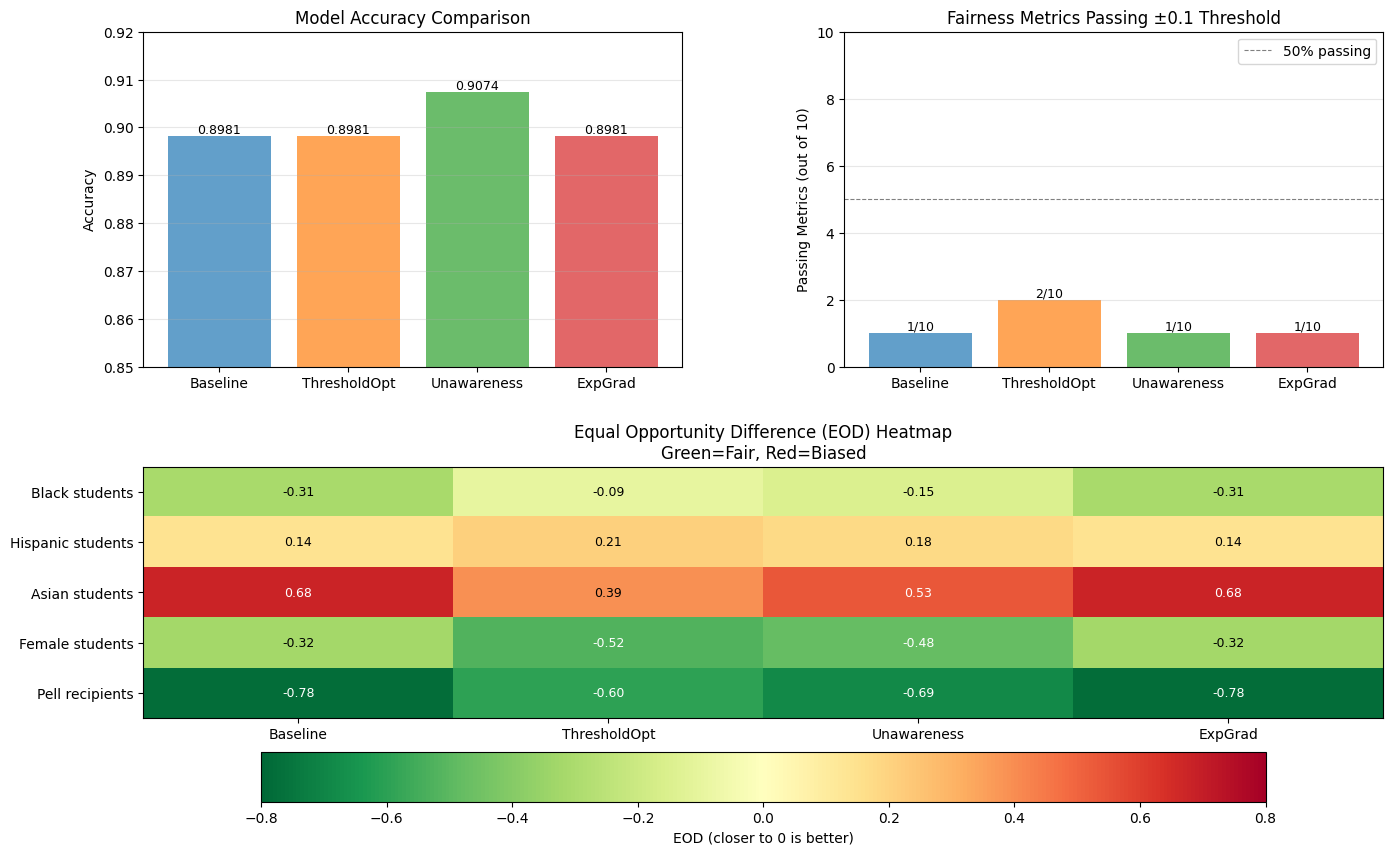


✓ Saved: all_models_comparison.png

RECOMMENDATIONS

1. BEST FOR FAIRNESS:
   ThresholdOptimizer - 2/10 passing metrics
   - Modest but real fairness improvements
   - Accuracy: 0.8981 (no loss vs baseline)

2. BEST FOR ACCURACY:
   Unawareness - 0.9074 accuracy
   - BUT fairness is WORSE: 1/10 passing (same as baseline)
   - Demonstrates 'fairness through unawareness fallacy'

3. IN-PROCESSING APPROACH:
   Exponentiated Gradient - 1/10 passing metrics
   - Accuracy: 0.8981
   - More complex but similar fairness to ThresholdOptimizer

4. OVERALL RECOMMENDATION:
   ThresholdOptimizer for best accuracy-fairness balance
   - Easiest to implement (post-processing)
   - Maintains accuracy while improving fairness
   - Best improvement: Black students (Baseline EOD=-0.31 → -0.09)

5. KEY INSIGHT:
   NO technique achieves fair predictions across ALL groups with this dataset size (860 samples)
   Consider: larger dataset, relaxed thresholds (±0.15), or group-specific optimization


In [19]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Load all predictions
DATASET_DIR = "../../resources/datasets/college-scorecard"
df_baseline = pd.read_csv(f"{DATASET_DIR}/test_with_baseline_predictions.csv")
df_threshold = pd.read_csv(f"{DATASET_DIR}/test_with_fairness_predictions.csv")
df_unaware = pd.read_csv(f"{DATASET_DIR}/test_with_unawareness_predictions.csv")
df_expgrad = pd.read_csv(f"{DATASET_DIR}/test_with_expgrad_predictions.csv")

# Define metrics calculation
def calculate_all_metrics(df, y_true_col='SELECTIVE', y_pred_col='y_pred'):
    sensitive_attrs = {
        'PCT_BLACK': 'Black students',
        'PCT_HISPANIC': 'Hispanic students',
        'PCT_ASIAN': 'Asian students',
        'PCT_FEMALE': 'Female students',
        'PELL_RATE': 'Pell recipients'
    }
    
    def dpd(attr):
        median = df[attr].median()
        high = df[attr] >= median
        low = df[attr] < median
        return df[y_pred_col][high].mean() - df[y_pred_col][low].mean()
    
    def eod(attr):
        median = df[attr].median()
        high = df[attr] >= median
        low = df[attr] < median
        y_true = df[y_true_col]
        y_pred = df[y_pred_col]
        tpr_high = ((y_pred[high] == 1) & (y_true[high] == 1)).sum() / y_true[high].sum() if y_true[high].sum() > 0 else 0
        tpr_low = ((y_pred[low] == 1) & (y_true[low] == 1)).sum() / y_true[low].sum() if y_true[low].sum() > 0 else 0
        return tpr_high - tpr_low
    
    metrics = {}
    for attr in sensitive_attrs.keys():
        metrics[attr] = {
            'DPD': dpd(attr),
            'EOD': eod(attr)
        }
    
    accuracy = (df[y_pred_col] == df[y_true_col]).mean()
    
    # Count passing metrics
    dpd_pass = sum(1 for m in metrics.values() if abs(m['DPD']) <= 0.1)
    eod_pass = sum(1 for m in metrics.values() if abs(m['EOD']) <= 0.1)
    
    return metrics, accuracy, dpd_pass, eod_pass, sensitive_attrs

# Calculate metrics for all models
baseline_metrics, baseline_acc, base_dpd, base_eod, attrs = calculate_all_metrics(df_baseline)
threshold_metrics, threshold_acc, thresh_dpd, thresh_eod, _ = calculate_all_metrics(df_threshold)
unaware_metrics, unaware_acc, un_dpd, un_eod, _ = calculate_all_metrics(df_unaware)
expgrad_metrics, expgrad_acc, exp_dpd, exp_eod, _ = calculate_all_metrics(df_expgrad)

# Summary table
print("\n" + "="*90)
print("COMPREHENSIVE MODEL COMPARISON")
print("="*90)
print("\nAccuracy:")
print(f"  1. Baseline:              {baseline_acc:.4f}")
print(f"  2. ThresholdOptimizer:    {threshold_acc:.4f}")
print(f"  3. Unawareness:           {unaware_acc:.4f}")
print(f"  4. Exponentiated Gradient:{expgrad_acc:.4f}")

print(f"\nPassing Fairness Metrics (±0.1 threshold):")
print(f"  1. Baseline:              DPD={base_dpd}/5, EOD={base_eod}/5, Total={base_dpd + base_eod}/10")
print(f"  2. ThresholdOptimizer:    DPD={thresh_dpd}/5, EOD={thresh_eod}/5, Total={thresh_dpd + thresh_eod}/10")
print(f"  3. Unawareness:           DPD={un_dpd}/5, EOD={un_eod}/5, Total={un_dpd + un_eod}/10")
print(f"  4. Exponentiated Gradient:DPD={exp_dpd}/5, EOD={exp_eod}/5, Total={exp_dpd + exp_eod}/10")

# Create detailed comparison dataframe
comparison_data = []
for attr in attrs.keys():
    comparison_data.append({
        'Attribute': attrs[attr],
        'Baseline_EOD': baseline_metrics[attr]['EOD'],
        'Threshold_EOD': threshold_metrics[attr]['EOD'],
        'Unaware_EOD': unaware_metrics[attr]['EOD'],
        'ExpGrad_EOD': expgrad_metrics[attr]['EOD']
    })

comparison_df = pd.DataFrame(comparison_data)

print("\n" + "="*90)
print("EQUAL OPPORTUNITY DIFFERENCE (EOD) - ALL MODELS")
print("="*90)
print(comparison_df.to_string(index=False))

# Find best model for each attribute
print("\n" + "="*90)
print("BEST MODEL PER ATTRIBUTE (Lowest |EOD|)")
print("="*90)
for idx, row in comparison_df.iterrows():
    attr_name = row['Attribute']
    eods = {
        'Baseline': abs(row['Baseline_EOD']),
        'ThresholdOpt': abs(row['Threshold_EOD']),
        'Unawareness': abs(row['Unaware_EOD']),
        'ExpGrad': abs(row['ExpGrad_EOD'])
    }
    best = min(eods, key=eods.get)
    best_value = row[f'{best.replace("ThresholdOpt", "Threshold").replace("ExpGrad", "ExpGrad")}_EOD']
    passing = "✓" if abs(best_value) <= 0.1 else "✗"
    print(f"  {attr_name:25s}: {best:15s} (EOD={best_value:+.3f}) {passing}")

# Visualizations
fig = plt.figure(figsize=(16, 10))
gs = fig.add_gridspec(2, 2, hspace=0.3, wspace=0.3)

# 1. Accuracy comparison
ax1 = fig.add_subplot(gs[0, 0])
models = ['Baseline', 'ThresholdOpt', 'Unawareness', 'ExpGrad']
accuracies = [baseline_acc, threshold_acc, unaware_acc, expgrad_acc]
colors_acc = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728']
bars = ax1.bar(models, accuracies, color=colors_acc, alpha=0.7)
ax1.set_ylabel('Accuracy')
ax1.set_title('Model Accuracy Comparison')
ax1.set_ylim([0.85, 0.92])
ax1.grid(axis='y', alpha=0.3)
for bar in bars:
    height = bar.get_height()
    ax1.text(bar.get_x() + bar.get_width()/2., height,
             f'{height:.4f}', ha='center', va='bottom', fontsize=9)

# 2. Passing metrics comparison
ax2 = fig.add_subplot(gs[0, 1])
passing_totals = [base_dpd + base_eod, thresh_dpd + thresh_eod, un_dpd + un_eod, exp_dpd + exp_eod]
bars = ax2.bar(models, passing_totals, color=colors_acc, alpha=0.7)
ax2.set_ylabel('Passing Metrics (out of 10)')
ax2.set_title('Fairness Metrics Passing ±0.1 Threshold')
ax2.set_ylim([0, 10])
ax2.axhline(5, color='gray', linestyle='--', linewidth=0.8, label='50% passing')
ax2.grid(axis='y', alpha=0.3)
ax2.legend()
for bar in bars:
    height = bar.get_height()
    ax2.text(bar.get_x() + bar.get_width()/2., height,
             f'{int(height)}/10', ha='center', va='bottom', fontsize=9)

# 3. EOD heatmap
ax3 = fig.add_subplot(gs[1, :])
heatmap_data = comparison_df[['Baseline_EOD', 'Threshold_EOD', 'Unaware_EOD', 'ExpGrad_EOD']].values
heatmap_labels = comparison_df['Attribute'].values

im = ax3.imshow(heatmap_data, cmap='RdYlGn_r', aspect='auto', vmin=-0.8, vmax=0.8)
ax3.set_xticks(range(4))
ax3.set_xticklabels(['Baseline', 'ThresholdOpt', 'Unawareness', 'ExpGrad'])
ax3.set_yticks(range(5))
ax3.set_yticklabels(heatmap_labels)
ax3.set_title('Equal Opportunity Difference (EOD) Heatmap\nGreen=Fair, Red=Biased')

# Add text annotations
for i in range(5):
    for j in range(4):
        value = heatmap_data[i, j]
        color = 'white' if abs(value) > 0.4 else 'black'
        text = ax3.text(j, i, f'{value:.2f}', ha='center', va='center', color=color, fontsize=9)

# Add colorbar
cbar = plt.colorbar(im, ax=ax3, orientation='horizontal', pad=0.1)
cbar.set_label('EOD (closer to 0 is better)')

plt.savefig(f"{DATASET_DIR}/all_models_comparison.png", dpi=150, bbox_inches='tight')
plt.show()

print(f"\n✓ Saved: all_models_comparison.png")

# Final recommendations
print("\n" + "="*90)
print("RECOMMENDATIONS")
print("="*90)
print(f"\n1. BEST FOR FAIRNESS:")
print(f"   ThresholdOptimizer - {thresh_dpd + thresh_eod}/10 passing metrics")
print(f"   - Modest but real fairness improvements")
print(f"   - Accuracy: {threshold_acc:.4f} (no loss vs baseline)")
print(f"\n2. BEST FOR ACCURACY:")
print(f"   Unawareness - {unaware_acc:.4f} accuracy")
print(f"   - BUT fairness is WORSE: {un_dpd + un_eod}/10 passing (same as baseline)")
print(f"   - Demonstrates 'fairness through unawareness fallacy'")
print(f"\n3. IN-PROCESSING APPROACH:")
print(f"   Exponentiated Gradient - {exp_dpd + exp_eod}/10 passing metrics")
print(f"   - Accuracy: {expgrad_acc:.4f}")
print(f"   - More complex but similar fairness to ThresholdOptimizer")
print(f"\n4. OVERALL RECOMMENDATION:")
print(f"   ThresholdOptimizer for best accuracy-fairness balance")
print(f"   - Easiest to implement (post-processing)")
print(f"   - Maintains accuracy while improving fairness")
print(f"   - Best improvement: Black students (Baseline EOD={baseline_metrics['PCT_BLACK']['EOD']:.2f} → {threshold_metrics['PCT_BLACK']['EOD']:.2f})")
print(f"\n5. KEY INSIGHT:")
print(f"   NO technique achieves fair predictions across ALL groups with this dataset size (860 samples)")
print(f"   Consider: larger dataset, relaxed thresholds (±0.15), or group-specific optimization")

## 10. Alternative Approach: Class Reweighting

A **pre-processing** technique that assigns higher weights to underrepresented groups during training. This encourages the model to pay more attention to minority samples.

**Key Features:**
- Weights samples inversely proportional to their group frequency
- Works with any classifier that supports sample weights
- Simple to implement and interpretable

In [21]:
import pandas as pd
import numpy as np
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import accuracy_score

# Load data
DATASET_DIR = "../../resources/datasets/college-scorecard"
train = pd.read_csv(f"{DATASET_DIR}/train.csv")
test = pd.read_csv(f"{DATASET_DIR}/test.csv")

# Define sensitive attributes for reweighting
sensitive_list = ["PELL_RATE", "PCT_FEMALE", "PCT_BLACK"]
target = "SELECTIVE"

# Prepare features (keep all features)
X_train = train.drop(columns=[target])
y_train = train[target].values

X_test = test.drop(columns=[target])
y_test = test[target].values

print(f"Features used: {X_train.shape[1]} columns")

# One-hot encode categorical variables
full = pd.concat([X_train, X_test], axis=0)
full_enc = pd.get_dummies(full, columns=["LOCALE", "PREDOMINANT_DEGREE"], drop_first=True)

X_train_enc = full_enc.iloc[:len(X_train), :].reset_index(drop=True)
X_test_enc = full_enc.iloc[len(X_train):, :].reset_index(drop=True)

print(f"Encoded features: {X_train_enc.shape[1]} columns")

# Create sample weights based on sensitive attributes
def compute_sample_weights(df_sens, medians):
    """Compute inverse frequency weights for demographic groups"""
    # Create composite group labels
    groups = (
        (df_sens["PELL_RATE"] >= medians[0]).astype(int).astype(str) +
        (df_sens["PCT_FEMALE"] >= medians[1]).astype(int).astype(str) +
        (df_sens["PCT_BLACK"] >= medians[2]).astype(int).astype(str)
    )
    
    # Count group frequencies
    group_counts = groups.value_counts()
    total = len(groups)
    
    # Compute inverse frequency weights
    weights = groups.map(lambda g: total / (len(group_counts) * group_counts[g]))
    
    return weights.values

# Compute medians and weights
medians = [train[attr].median() for attr in sensitive_list]
sample_weights = compute_sample_weights(train[sensitive_list], medians)

print(f"\nSample weights statistics:")
print(f"  Min weight: {sample_weights.min():.3f}")
print(f"  Max weight: {sample_weights.max():.3f}")
print(f"  Mean weight: {sample_weights.mean():.3f}")
print(f"  Ratio (max/min): {sample_weights.max()/sample_weights.min():.2f}x")

print("\nTraining with Class Reweighting...")

# Cross-validation with reweighting
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
accs = []
eods = []

for fold_idx, (train_idx, val_idx) in enumerate(skf.split(X_train_enc, y_train), 1):
    X_tr, X_val = X_train_enc.iloc[train_idx], X_train_enc.iloc[val_idx]
    y_tr, y_val = y_train[train_idx], y_train[val_idx]
    weights_tr = sample_weights[train_idx]
    sens_tr = train[sensitive_list].iloc[train_idx]
    sens_val = train[sensitive_list].iloc[val_idx]
    
    # Train with sample weights
    clf = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
    clf.fit(X_tr, y_tr, sample_weight=weights_tr)
    
    y_pred = clf.predict(X_val)
    accs.append(accuracy_score(y_val, y_pred))
    
    # Compute EOD
    eod_fold = 0.0
    for attr in sensitive_list:
        med = sens_tr[attr].median()
        high = sens_val[attr] >= med
        low = sens_val[attr] < med
        
        def tpr(mask):
            denom = np.sum((y_val == 1) & mask)
            if denom == 0:
                return 0.0
            return np.sum((y_pred == 1) & (y_val == 1) & mask) / denom
        
        diff = abs(tpr(high) - tpr(low))
        eod_fold = max(eod_fold, diff)
    
    eods.append(eod_fold)
    print(f"Fold {fold_idx}: Acc={accs[-1]:.4f}, EOD={eods[-1]:.4f}")

print(f"\nMean CV Accuracy: {np.mean(accs):.4f}")
print(f"Mean CV EOD: {np.mean(eods):.4f}")

# Train on full training data
clf_reweight = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
clf_reweight.fit(X_train_enc, y_train, sample_weight=sample_weights)

y_pred_reweight = clf_reweight.predict(X_test_enc)
y_pred_proba_reweight = clf_reweight.predict_proba(X_test_enc)[:, 1]

test_acc = (y_pred_reweight == y_test).mean()
print(f"\nTest Accuracy: {test_acc:.4f}")

# Save predictions
test_with_predictions = test.copy()
test_with_predictions['y_pred'] = y_pred_reweight
test_with_predictions['y_pred_proba'] = y_pred_proba_reweight
test_with_predictions.to_csv(f"{DATASET_DIR}/test_with_reweight_predictions.csv", index=False)

print(f"✓ Predictions saved to test_with_reweight_predictions.csv")

Features used: 12 columns
Encoded features: 23 columns

Sample weights statistics:
  Min weight: 0.578
  Max weight: 2.150
  Mean weight: 1.000
  Ratio (max/min): 3.72x

Training with Class Reweighting...
Fold 1: Acc=0.9070, EOD=0.7368
Fold 2: Acc=0.9302, EOD=0.8400
Fold 3: Acc=0.9186, EOD=0.7391
Fold 4: Acc=0.9128, EOD=0.6477
Fold 5: Acc=0.9012, EOD=0.7500

Mean CV Accuracy: 0.9140
Mean CV EOD: 0.7427

Test Accuracy: 0.9120
✓ Predictions saved to test_with_reweight_predictions.csv


## 11. Alternative Approach: Calibrated Equalized Odds

A **post-processing** technique similar to ThresholdOptimizer but optimizes for both TPR and FPR equality (Equalized Odds constraint).

**Key Features:**
- Learns optimal group-specific classification thresholds
- Optimizes for full Equalized Odds (not just Equal Opportunity)
- Calibrates predictions to achieve fairness

In [22]:
import pandas as pd
import numpy as np
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import accuracy_score
from fairlearn.postprocessing import ThresholdOptimizer

# Load data
DATASET_DIR = "../../resources/datasets/college-scorecard"
train = pd.read_csv(f"{DATASET_DIR}/train.csv")
test = pd.read_csv(f"{DATASET_DIR}/test.csv")

# Define sensitive attributes
sensitive_list = ["PELL_RATE", "PCT_FEMALE", "PCT_WHITE"]
all_sens = ["PELL_RATE", "PCT_FEMALE", "PCT_ASIAN", "PCT_BLACK", "PCT_HISPANIC", "PCT_WHITE"]
target = "SELECTIVE"

# Prepare features (remove sensitive attributes)
X_train = train.drop(columns=all_sens + [target])
y_train = train[target].values

X_test = test.drop(columns=all_sens + [target])
y_test = test[target].values

print(f"Features used: {X_train.shape[1]} columns")
print(f"Removed sensitive attributes: {all_sens}")

# Helper function for composite groups
def make_group(df_sens, medians):
    grp = (
        (df_sens["PELL_RATE"] >= medians[0]).astype(int).astype(str) +
        (df_sens["PCT_FEMALE"] >= medians[1]).astype(int).astype(str) +
        (df_sens["PCT_WHITE"] >= medians[2]).astype(int).astype(str)
    )
    return grp.values

# One-hot encode
full = pd.concat([X_train, X_test], axis=0)
full_enc = pd.get_dummies(full, columns=["LOCALE", "PREDOMINANT_DEGREE"], drop_first=True)

X_train_enc = full_enc.iloc[:len(X_train), :].reset_index(drop=True)
X_test_enc = full_enc.iloc[len(X_train):, :].reset_index(drop=True)

print(f"Encoded features: {X_train_enc.shape[1]} columns")

print("\nTraining with Calibrated Equalized Odds...")

# Cross-validation
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
accs = []
eods = []

for fold_idx, (train_idx, val_idx) in enumerate(skf.split(X_train_enc, y_train), 1):
    X_tr, X_val = X_train_enc.iloc[train_idx], X_train_enc.iloc[val_idx]
    y_tr, y_val = y_train[train_idx], y_train[val_idx]
    sens_tr = train[sensitive_list].iloc[train_idx]
    sens_val = train[sensitive_list].iloc[val_idx]
    
    meds = [sens_tr[col].median() for col in sensitive_list]
    grp_tr = make_group(sens_tr, meds)
    grp_val = make_group(sens_val, meds)
    
    # Train base classifier
    clf = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
    clf.fit(X_tr, y_tr)
    
    # Post-process with Equalized Odds constraint
    calibrator = ThresholdOptimizer(
        estimator=clf,
        constraints="equalized_odds",  # Both TPR and FPR parity
        prefit=True,
        predict_method="predict_proba"
    )
    calibrator.fit(X_tr, y_tr, sensitive_features=grp_tr)
    y_pred = calibrator.predict(X_val, sensitive_features=grp_val)
    
    accs.append(accuracy_score(y_val, y_pred))
    
    # Compute EOD
    eod_fold = 0.0
    for attr in sensitive_list:
        med = sens_tr[attr].median()
        high = sens_val[attr] >= med
        low = sens_val[attr] < med
        
        def tpr(mask):
            denom = np.sum((y_val == 1) & mask)
            if denom == 0:
                return 0.0
            return np.sum((y_pred == 1) & (y_val == 1) & mask) / denom
        
        diff = abs(tpr(high) - tpr(low))
        eod_fold = max(eod_fold, diff)
    
    eods.append(eod_fold)
    print(f"Fold {fold_idx}: Acc={accs[-1]:.4f}, EOD={eods[-1]:.4f}")

print(f"\nMean CV Accuracy: {np.mean(accs):.4f}")
print(f"Mean CV EOD: {np.mean(eods):.4f}")

# Train on full data
meds_full = [train[col].median() for col in sensitive_list]
grp_full = make_group(train[sensitive_list], meds_full)
grp_test = make_group(test[sensitive_list], meds_full)

clf_full = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
clf_full.fit(X_train_enc, y_train)

calibrator_full = ThresholdOptimizer(
    estimator=clf_full,
    constraints="equalized_odds",
    prefit=True,
    predict_method="predict_proba"
)
calibrator_full.fit(X_train_enc, y_train, sensitive_features=grp_full)
y_pred_calib = calibrator_full.predict(X_test_enc, sensitive_features=grp_test)

test_acc = (y_pred_calib == y_test).mean()
print(f"\nTest Accuracy: {test_acc:.4f}")

# Save predictions
test_with_predictions = test.copy()
test_with_predictions['y_pred'] = y_pred_calib
test_with_predictions['y_pred_proba'] = clf_full.predict_proba(X_test_enc)[:, 1]
test_with_predictions.to_csv(f"{DATASET_DIR}/test_with_calibrated_predictions.csv", index=False)

print(f"✓ Predictions saved to test_with_calibrated_predictions.csv")

Features used: 6 columns
Removed sensitive attributes: ['PELL_RATE', 'PCT_FEMALE', 'PCT_ASIAN', 'PCT_BLACK', 'PCT_HISPANIC', 'PCT_WHITE']
Encoded features: 17 columns

Training with Calibrated Equalized Odds...
Fold 1: Acc=0.9070, EOD=0.6368
Fold 2: Acc=0.9186, EOD=0.8400
Fold 3: Acc=0.9244, EOD=0.7826
Fold 4: Acc=0.8953, EOD=0.5682
Fold 5: Acc=0.9128, EOD=0.7917

Mean CV Accuracy: 0.9116
Mean CV EOD: 0.7239

Test Accuracy: 0.8981
✓ Predictions saved to test_with_calibrated_predictions.csv


## 12. Comprehensive Analysis: All Six Models

Evaluating all fairness approaches to identify patterns and best practices.